# SQLiteData Feed 验证 — BTC-USD

验证 `sqlitefeed.py` 从 `csv_files/BTC-USD.db` 读取数据并执行一次简单回测。

In [1]:
import sys
import datetime
import backtrader as bt
from sqlitefeed import SQLiteData

## 1. 加载数据 & 基本信息

In [2]:
DB_PATH = 'csv_files/BTC-USD.db'
FROM = datetime.datetime(2020, 1, 1)
TO   = datetime.datetime(2020, 12, 31)

cerebro = bt.Cerebro()
data = SQLiteData(dataname=DB_PATH, fromdate=FROM, todate=TO)
cerebro.adddata(data, name='BTC-USD')

class DataInfo(bt.Strategy):
    def stop(self):
        d = self.data
        n = len(d)
        print(f'bars loaded : {n}')
        print(f'first bar   : {bt.num2date(d.datetime[-n+1])}  O={d.open[-n+1]:.2f}  C={d.close[-n+1]:.2f}')
        print(f'last  bar   : {bt.num2date(d.datetime[0])}  O={d.open[0]:.2f}  C={d.close[0]:.2f}')

cerebro.addstrategy(DataInfo)
cerebro.run()

bars loaded : 365
first bar   : 2020-01-01 00:00:00  O=7194.89  C=7200.17
last  bar   : 2020-12-30 00:00:00  O=27360.09  C=28840.95


## 2. 用 pandas 查看原始数据

In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(
    'SELECT timestamp, open, high, low, close, volume FROM ohlc ORDER BY timestamp',
    conn,
)
conn.close()

df['date'] = pd.to_datetime(df['timestamp'], unit='s', utc=True).dt.tz_convert(None)
df = df.drop(columns='timestamp').set_index('date')
print(f'全部数据: {len(df)} 行，{df.index[0].date()} ~ {df.index[-1].date()}')
df.head()

全部数据: 3853 行，2014-09-17 ~ 2025-04-02


,open,high,low,close,volume
date,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100


## 3. 简单回测：SMA 金叉死叉策略

In [4]:
class SMACross(bt.Strategy):
    params = (('fast', 10), ('slow', 30))

    def __init__(self):
        sma_fast = bt.ind.SMA(period=self.p.fast)
        sma_slow = bt.ind.SMA(period=self.p.slow)
        self.crossover = bt.ind.CrossOver(sma_fast, sma_slow)

    def next(self):
        if not self.position:
            if self.crossover > 0:
                self.buy()
        elif self.crossover < 0:
            self.sell()

cerebro = bt.Cerebro()
cerebro.adddata(SQLiteData(dataname=DB_PATH, fromdate=FROM, todate=TO), name='BTC-USD')
cerebro.addstrategy(SMACross)
cerebro.broker.setcash(100_000)
cerebro.broker.setcommission(0.001)
cerebro.addsizer(bt.sizers.AllInSizerInt)
cerebro.addanalyzer(bt.analyzers.SQN, _name='sqn')
cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')

start_val = cerebro.broker.getvalue()
results = cerebro.run()
end_val = cerebro.broker.getvalue()
strat = results[0]

print(f'初始资金 : {start_val:,.0f}')
print(f'最终资金 : {end_val:,.2f}')
print(f'收益率   : {(end_val/start_val - 1)*100:.2f}%')
print(f'SQN      : {strat.analyzers.sqn.get_analysis()["sqn"]:.3f}')

初始资金 : 100,000
最终资金 : 406,899.58
收益率   : 306.90%
SQN      : 1.309


## 4. 收盘价走势图

/var/folders/h9/7mryd5yj46v9fjg4wx8rfymr0000gp/T/ipykernel_78268/4222936429.py:11: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h9/7mryd5yj46v9fjg4wx8rfymr0000gp/T/ipykernel_78268/4222936429.py:11: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h9/7mryd5yj46v9fjg4wx8rfymr0000gp/T/ipykernel_78268/4222936429.py:11: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h9/7mryd5yj46v9fjg4wx8rfymr0000gp/T/ipykernel_78268/4222936429.py:11: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h9/7mryd5yj46v9fjg4wx8rfymr0000gp/T/ipykernel_78268/4222936429.py:11: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/liuji/gitrepo

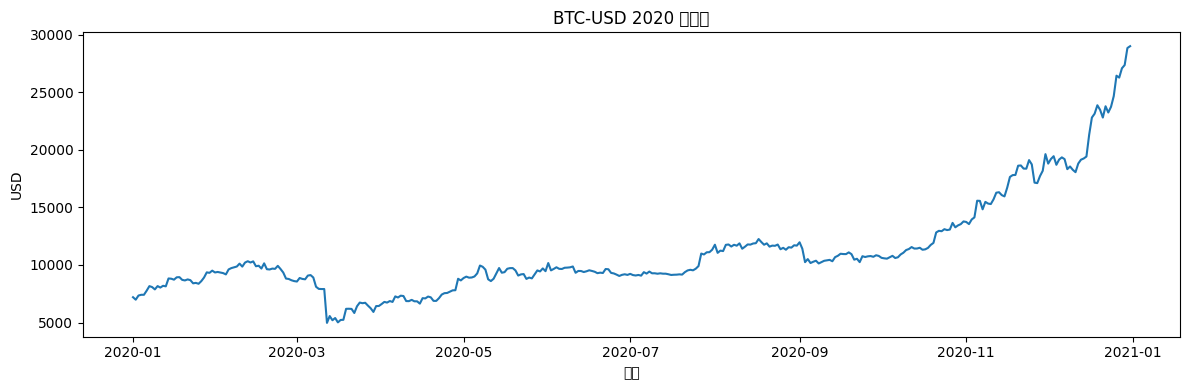

In [5]:
import matplotlib.pyplot as plt

mask = (df.index >= str(FROM.date())) & (df.index <= str(TO.date()))
df_2020 = df.loc[mask]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_2020.index, df_2020['close'])
ax.set_title('BTC-USD 2020 收盘价')
ax.set_xlabel('日期')
ax.set_ylabel('USD')
plt.tight_layout()
plt.show()